In [9]:
# Imports
import capytaine as cpt
from capytaine.io.legacy import export_hydrostatics
from capytaine.io.meshio import load_from_meshio
import os
import pygmsh
import gmsh
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt

In [10]:
# Waves and frequencies definitions
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10

# Define waves object
amplitude   = 0.005 # m
phase       = 0 # degrees
wavedir     = 0 # degrees

rho = 1025

In [11]:

wavefreq = 0.4
f1 = wavefreq
nfreq = 10

# regular (for testing/setup)
amplitude = 0.1
phase = 0
wavedir = 0


In [ ]:

# provided by OSU
float_mass_properties = {
    'mass': 248.721,
    'CG': [0.01, 0, 0.06],
    'MOI': [66.1686, 65.3344, 17.16],
}

spar_mass_properties = {
    'mass': 175.536,
    'CG': [0, 0, -1.3],
    'MOI': [253.6344, 250.4558, 12.746],
}

water_depth = 2.7 # depth of wave flume

# mesh
mesh_size_factor = 0.3
r1 = 1.0/2  # top radius
r2 = 0.4/2  # bottom radius
h1 = 0.5  
h2 = 0.21
freeboard = 0.3
r3 = 0.05  # hole radius
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    cyl = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    cone = geom.add_cone([0, 0, -h1], [0, 0, -h2], r1, r2)
    geom.translate(cyl, [0, 0, freeboard])
    geom.translate(cone, [0, 0, freeboard]) 
    tmp = geom.boolean_union([cyl, cone])
    bar = geom.add_cylinder([0, 0, 10], [0,0,-20], r3)
    geom.boolean_difference(tmp, bar)
    mesh_float = geom.generate_mesh()

# lid
mesh_obj_float = load_from_meshio(mesh_float, 'float')
lid_mesh = mesh_obj_float.generate_lid(z=-1e-2)

# floating body
float_fb = cpt.FloatingBody(mesh=mesh_obj_float, lid_mesh=lid_mesh, name="float")

# show
#float_fb.show_matplotlib()

# mass properties float
cm_float = np.array(float_mass_properties['CG'])
float_fb.center_of_mass = cm_float
float_fb.rotation_center = float_fb.center_of_mass

float_fb.add_all_rigid_body_dofs()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([
    float_mass_properties['mass'],float_mass_properties['mass'],
    float_mass_properties['mass'],float_mass_properties['MOI'][0],
    float_mass_properties['MOI'][1],float_mass_properties['MOI'][2]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(float_fb.dofs),
                                    'radiating_dof': list(float_fb.dofs)},
                            name="inertia_matrix")

float_fb.inertia_matrix = rigid_inertia_matrix_xr
float_fb.hydrostatic_stiffness = float_fb.immersed_part().compute_hydrostatic_stiffness()
float_fb.compute_hydrostatics()

{'g': 9.81,
 'rho': 1000.0,
 'center_of_mass': array([0.  , 0.  , 0.06]),
 'wet_surface_area': np.float64(1.6765136703394878),
 'disp_volumes': array([0.23959128, 0.23959128, 0.23959128]),
 'disp_volume': np.float64(0.2395912807595307),
 'disp_mass': np.float64(239.59128075953072),
 'center_of_buoyancy': array([-4.62479216e-06,  6.79756407e-07, -1.61790252e-01]),
 'waterplane_center': array([-5.58439239e-06,  3.99319032e-05,  0.00000000e+00]),
 'waterplane_area': np.float64(0.7774645236682265),
 'transversal_metacentric_radius': np.float64(0.204156788607068),
 'longitudinal_metacentric_radius': np.float64(0.2041748691617168),
 'transversal_metacentric_height': np.float64(-0.01763346347506345),
 'longitudinal_metacentric_height': np.float64(-0.017615382920414674),
 'hydrostatic_stiffness': <xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00

In [13]:
# mesh
mesh_size_factor = 0.1
r1 = 0.45/2  # body
r2 = 0.45  # plate
r3 = 0.10/2  # bar
h1 = 1.20  
h2 = 0.01
h3a = 3.684 - 2.05
submergence = 2.05 - h1 - h2

with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', mesh_size_factor)
    body = geom.add_cylinder([0, 0, 0], [0, 0, -h1], r1)
    geom.translate(body, [0, 0, -submergence])
    plate = geom.add_cylinder([0, 0, 0], [0, 0, -h2], r2)
    geom.translate(plate, [0, 0, -(submergence+h1)])
    bar = geom.add_cylinder([0, 0, h3a], [0, 0, -(h3a+submergence)], r3)
    geom.boolean_union([bar, body, plate])
    mesh_spar = geom.generate_mesh()

# lid
mesh_obj_spar = load_from_meshio(mesh_spar, 'spar')
lid_mesh = mesh_obj_spar.generate_lid(z=-1e-2)

# floating body
spar_fb = cpt.FloatingBody(mesh=mesh_obj_spar, lid_mesh=lid_mesh, name="spar")

#spar_fb.show_matplotlib()

# mass properties spar
cm_spar = np.array(spar_mass_properties['CG'])
spar_fb.center_of_mass = cm_spar
spar_fb.rotation_center = spar_fb.center_of_mass

spar_fb.add_all_rigid_body_dofs()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([
    spar_mass_properties['mass'],spar_mass_properties['mass'],
    spar_mass_properties['mass'],spar_mass_properties['MOI'][0],
    spar_mass_properties['MOI'][1],spar_mass_properties['MOI'][2]]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(spar_fb.dofs),
                                    'radiating_dof': list(spar_fb.dofs)},
                            name="inertia_matrix")

spar_fb.inertia_matrix = rigid_inertia_matrix_xr
spar_fb.hydrostatic_stiffness = spar_fb.immersed_part().compute_hydrostatic_stiffness()
spar_fb.compute_hydrostatics()

{'g': 9.81,
 'rho': 1000.0,
 'center_of_mass': array([ 0. ,  0. , -1.3]),
 'wet_surface_area': np.float64(3.2460086766507077),
 'disp_volumes': array([0.20265689, 0.20265689, 0.20265689]),
 'disp_volume': np.float64(0.20265689154076563),
 'disp_mass': np.float64(202.65689154076563),
 'center_of_buoyancy': array([-4.13580995e-06, -5.52285553e-06, -1.42806983e+00]),
 'waterplane_center': array([ 8.11164117e-05, -1.24615027e-04,  0.00000000e+00]),
 'waterplane_area': np.float64(0.007336884528811135),
 'transversal_metacentric_radius': np.float64(1.051456883775734e-05),
 'longitudinal_metacentric_radius': np.float64(8.3947433532811e-06),
 'transversal_metacentric_height': np.float64(-0.12805931770359766),
 'longitudinal_metacentric_height': np.float64(-0.1280614375290821),
 'hydrostatic_stiffness': <xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,

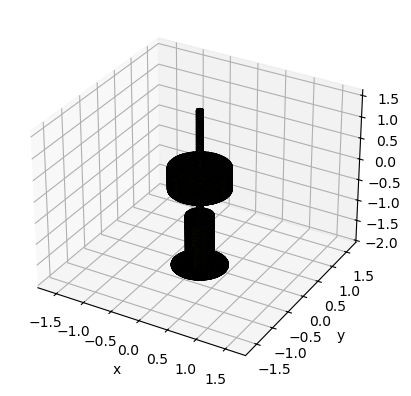

In [14]:
lupa_fb = spar_fb + float_fb

lupa_fb.show_matplotlib()

In [15]:
rho = 1025
g = 9.81

test_matrix = xr.Dataset(coords={
    "omega": np.linspace(f1*2*np.pi, nfreq*f1*2*np.pi, nfreq, True),
    "radiating_dof": list(lupa_fb.dofs),
    "wave_direction": [0],
    "water_depth": [water_depth],
    "rho": [rho],
    "g": [g]
    })

solver = cpt.BEMSolver()
write_info = {'hydrostatics': True,'mesh': False,'wavelength': False,'wavenumber': False}
dataset = solver.fill_dataset(test_matrix, lupa_fb.immersed_part(), n_jobs=1, **write_info)

[13:29:00] WARNING  Mesh resolution for 65 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 15.080 to 25.133.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

In [ ]:
body_coord = dataset.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [spar_fb, float_fb]])
cob = np.vstack([b.center_of_buoyancy for b in [spar_fb, float_fb]])
volumes = np.array([b.immersed_part().volume for b in [spar_fb, float_fb]], dtype=float)

dataset["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
dataset["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
dataset["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

input_data_dir = os.getcwd()
output_dir = os.path.join(input_data_dir, '')

dataset['radiating_dof'] = dataset['radiating_dof'].astype(str)
dataset['influenced_dof'] = dataset['influenced_dof'].astype(str)

cpt.export_dataset(os.path.join(output_dir, 'lupa_hs.nc'), dataset)